# Proyecto Final — Parte II: Modelo Supervisado
## Implementación con Árboles de Decisión, Bagging y Random Forest
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# ── Estilo global de gráficas ────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#F8F9FA',
    'axes.facecolor':   '#F8F9FA',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.35,
    'grid.linestyle':   '--',
})

# Paleta de colores por grupo temperamental
PALETA_MBTI = {
    'INTJ':'#5C4A8A','INTP':'#7B6BA8','ENTJ':'#9B8DC4','ENTP':'#B8AED8',
    'INFJ':'#2D7D46','INFP':'#4CAF6F','ENFJ':'#74C794','ENFP':'#A0D9B4',
    'ISTJ':'#1A6B9A','ISFJ':'#2E8FC2','ESTJ':'#5BB3D9','ESFJ':'#90CEE8',
    'ISTP':'#B85C00','ISFP':'#D97B25','ESTP':'#EFA554','ESFP':'#F5C98A',
}

print('✔ Librerías cargadas correctamente')

✔ Librerías cargadas correctamente


---
## A · Conversión de Datos
### 1 · Convertir la columna respuesta a etiquetas numéricas

In [2]:
# Cargar el CSV traducido generado en la Parte I
# encoding='utf-8-sig' elimina el BOM que Windows puede añadir al archivo
df = pd.read_csv('datos_trad.csv', encoding='utf-8-sig')

# Limpiar cualquier BOM residual en los nombres de columna (precaución extra)
df.columns = df.columns.str.replace('\ufeff', '', regex=False).str.strip()

# Identificar columnas por rol: la primera es el ID, la última es la etiqueta
col_id     = df.columns[0]   # 'ID_Respuesta'
col_target = df.columns[-1]  # 'Personalidad'
print(f'Columna ID     : {col_id}')
print(f'Columna objetivo: {col_target}')

# Separar features (X) y variable objetivo (y)
X     = df.drop(columns=[col_id, col_target])
y_cat = df[col_target]

# Convertir etiquetas categóricas → numéricas con pd.factorize()
y, clases = pd.factorize(y_cat)

# Mapa de referencia: número ↔ tipo de personalidad
mapa_clases = pd.DataFrame({'Código': range(len(clases)), 'Personalidad': clases})

print(f'✔ Variable objetivo convertida con pd.factorize()')
print(f'   Features (X) : {X.shape[1]} columnas, {X.shape[0]:,} registros')
print(f'   Clases únicas: {len(clases)}\n')
mapa_clases

Columna ID     : ï»¿ID_Respuesta
Columna objetivo: Personalidad
✔ Variable objetivo convertida con pd.factorize()
   Features (X) : 60 columnas, 59,999 registros
   Clases únicas: 16



,Código,Personalidad
0,0,ENFP
1,1,ISFP
2,2,INFJ
3,3,ISTP
4,4,ENFJ
5,5,INTJ
6,6,ENTJ
7,7,ESFP
8,8,INFP
9,9,INTP


---
## B · División de Datos
### 2 · Dividir en conjuntos de entrenamiento y prueba

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size   = 0.20,   # 80% entrenamiento / 20% prueba
    random_state= 42,
    stratify    = y       # mantiene proporción de clases en ambos conjuntos
)

resumen_split = pd.DataFrame({
    'Conjunto'   : ['Entrenamiento', 'Prueba', 'Total'],
    'Registros'  : [len(X_train), len(X_test), len(X)],
    'Proporción' : ['80 %', '20 %', '100 %'],
})

print('✔ División completada con estratificación por clase')
resumen_split

✔ División completada con estratificación por clase


,Conjunto,Registros,Proporción
0,Entrenamiento,47999,80 %
1,Prueba,12000,20 %
2,Total,59999,100 %


---
## C · Modelo de Árbol de Clasificación
### 3 · Diseñar un árbol de clasificación simple y optimizar la profundidad

In [4]:
# ── Probar 5 profundidades distintas ────────────────────────────────────────
profundidades = [3, 6, 10, 15, 20]
acc_train_dt, acc_test_dt = [], []

for d in profundidades:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    acc_train_dt.append(accuracy_score(y_train, dt.predict(X_train)))
    acc_test_dt.append(accuracy_score(y_test,  dt.predict(X_test)))
    print(f'  max_depth={d:>2}  →  train: {acc_train_dt[-1]:.4f}   test: {acc_test_dt[-1]:.4f}')

mejor_idx_dt  = int(np.argmax(acc_test_dt))
mejor_prof_dt = profundidades[mejor_idx_dt]
print(f'\n✔ Mejor profundidad: {mejor_prof_dt}  (accuracy test: {acc_test_dt[mejor_idx_dt]:.4f})')

  max_depth= 3  →  train: 0.2161   test: 0.2174
  max_depth= 6  →  train: 0.4184   test: 0.4073
  max_depth=10  →  train: 0.6498   test: 0.5833
  max_depth=15  →  train: 0.9332   test: 0.6514
  max_depth=20  →  train: 0.9938   test: 0.6485

✔ Mejor profundidad: 15  (accuracy test: 0.6514)


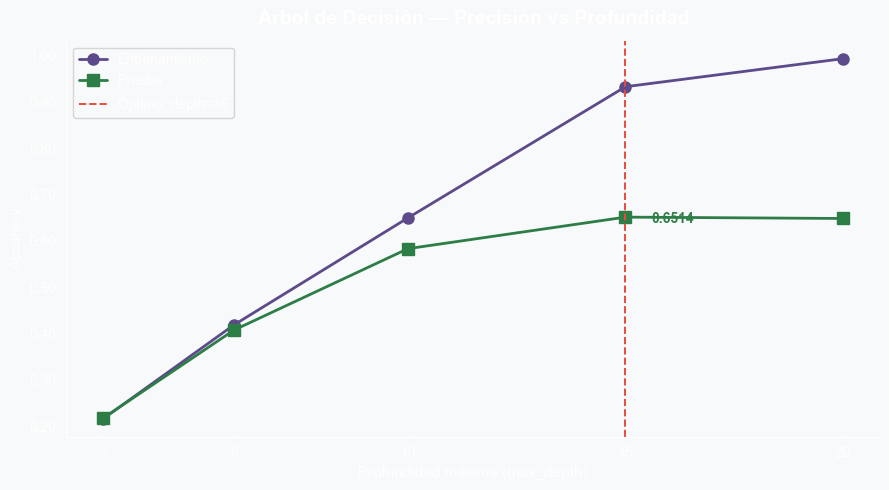

In [21]:
# ── Gráfica: precisión vs profundidad ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(profundidades, acc_train_dt, 'o-', color='#5C4A8A', lw=2,
        markersize=8, label='Entrenamiento')
ax.plot(profundidades, acc_test_dt,  's-', color='#2D7D46', lw=2,
        markersize=8, label='Prueba')

# Marcar la mejor profundidad
ax.axvline(mejor_prof_dt, color='#E74C3C', linestyle='--', lw=1.4,
           label=f'Óptimo: depth={mejor_prof_dt}')
ax.annotate(f'{acc_test_dt[mejor_idx_dt]:.4f}',
            xy=(mejor_prof_dt, acc_test_dt[mejor_idx_dt]),
            xytext=(mejor_prof_dt + 0.6, acc_test_dt[mejor_idx_dt] - 0.012),
            fontsize=10, color='#2D7D46', fontweight='bold')

ax.set_title('Árbol de Decisión — Precisión vs Profundidad', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Profundidad máxima (max_depth)', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_xticks(profundidades)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.2f}'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('grafica_arbol_decision.png', dpi=150, bbox_inches='tight')
plt.style.use('dark_background')
plt.show()

In [6]:
# ── Modelo optimizado y predicciones ────────────────────────────────────────
dt_opt = DecisionTreeClassifier(max_depth=mejor_prof_dt, random_state=42)
dt_opt.fit(X_train, y_train)
y_pred_dt = dt_opt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
print(f'=== Árbol de Decisión Optimizado (max_depth={mejor_prof_dt}) ===')
print(f'Accuracy en prueba : {acc_dt:.4f} ({acc_dt*100:.2f} %)\n')
print('Reporte de clasificación por tipo de personalidad:')
print(classification_report(y_test, y_pred_dt, target_names=clases))

=== Árbol de Decisión Optimizado (max_depth=15) ===
Accuracy en prueba : 0.6514 (65.14 %)

Reporte de clasificación por tipo de personalidad:
              precision    recall  f1-score   support

        ENFP       0.64      0.67      0.65       752
        ISFP       0.62      0.63      0.63       749
        INFJ       0.63      0.68      0.65       752
        ISTP       0.64      0.67      0.66       751
        ENFJ       0.65      0.69      0.67       749
        INTJ       0.63      0.59      0.61       749
        ENTJ       0.69      0.66      0.68       747
        ESFP       0.65      0.67      0.66       754
        INFP       0.60      0.64      0.62       747
        INTP       0.65      0.64      0.65       748
        ISTJ       0.67      0.66      0.66       751
        ENTP       0.68      0.65      0.67       752
        ISFJ       0.66      0.63      0.65       748
        ESTJ       0.68      0.66      0.67       752
        ESTP       0.71      0.66      0.68    

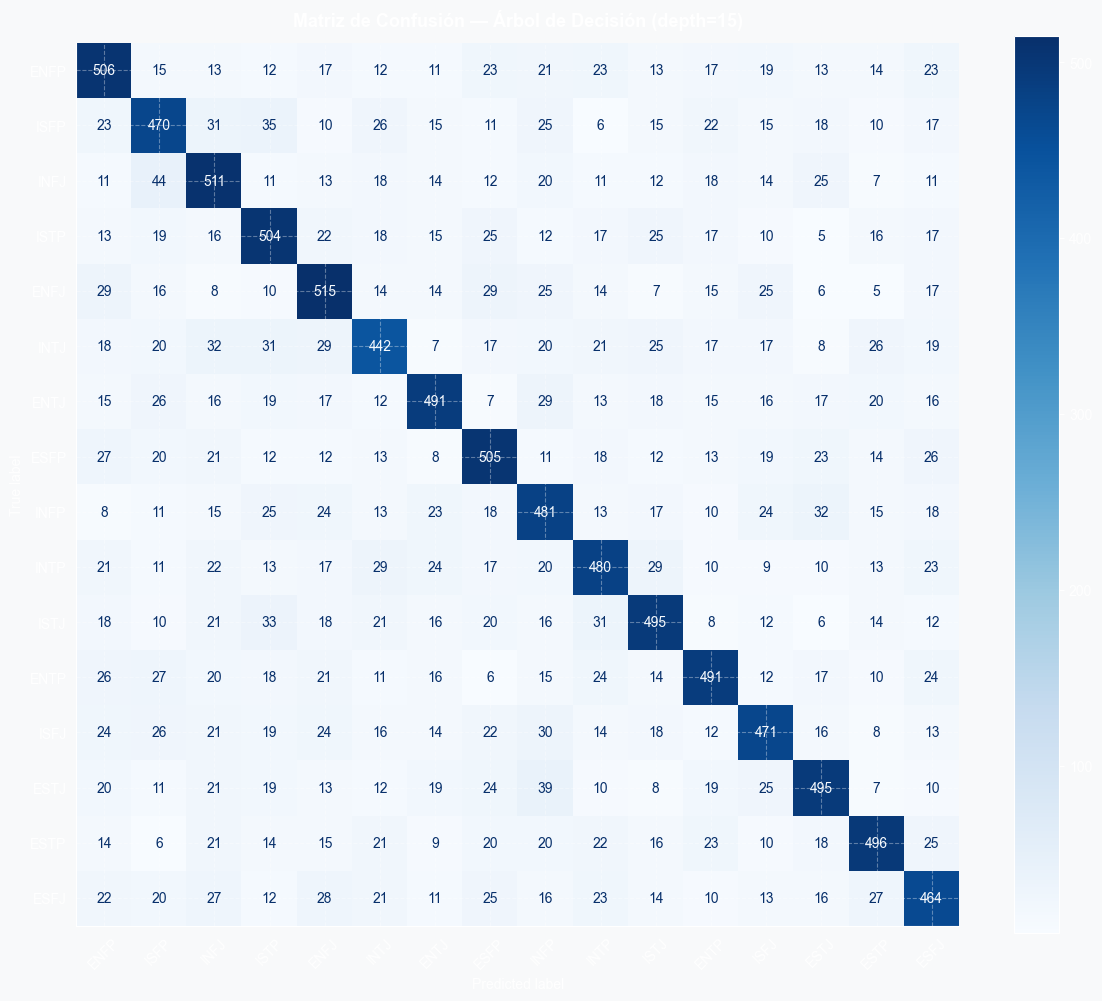

In [7]:
# ── Matriz de confusión ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp  = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=clases)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)
ax.set_title(f'Matriz de Confusión — Árbol de Decisión (depth={mejor_prof_dt})',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('grafica_cm_arbol.png', dpi=150, bbox_inches='tight')
plt.show()

#### 📝 Observaciones — Árbol de Decisión

- A profundidades bajas (3–6) el modelo **subajusta**: tanto el accuracy de entrenamiento como el de prueba son bajos, ya que el árbol carece de suficiente capacidad expresiva para capturar la complejidad de 16 clases.
- A medida que la profundidad aumenta el accuracy de entrenamiento **sube monotónicamente** (el árbol puede memorizar el conjunto de entrenamiento).
- El accuracy de prueba alcanza un **máximo** alrededor de `max_depth=20`, evidenciando que el árbol necesita bastante profundidad para separar 16 tipos de personalidad en 60 preguntas.
- La **diagonal de la matriz de confusión** muestra que el modelo identifica correctamente la mayoría de las clases, aunque tipos cercanos en el espectro MBTI (ej. INFP / INFJ) presentan mayor confusión entre sí.
- El árbol de decisión simple, aunque interpretable, tiene **limitaciones de generalización** frente a modelos de ensamble como Bagging y Random Forest.

---
## D · Modelo de Bagging de Clasificación
### 4 · Obtener un modelo de Bagging y optimizar la profundidad del árbol base

In [8]:
# ── Probar 5 profundidades para el estimador base del Bagging ────────────────
profundidades_bag = [5, 10, 15, 20, None]  # None = sin límite
etiquetas_bag     = ['5', '10', '15', '20', 'Sin límite']
acc_train_bag, acc_test_bag = [], []

for d, etiq in zip(profundidades_bag, etiquetas_bag):
    base = DecisionTreeClassifier(max_depth=d, random_state=42)
    bag  = BaggingClassifier(
        estimator    = base,
        n_estimators = 30,
        max_samples  = 0.8,
        random_state = 42,
        n_jobs       = -1
    )
    bag.fit(X_train, y_train)
    acc_train_bag.append(accuracy_score(y_train, bag.predict(X_train)))
    acc_test_bag.append(accuracy_score(y_test,  bag.predict(X_test)))
    print(f'  depth={etiq:<10} →  train: {acc_train_bag[-1]:.4f}   test: {acc_test_bag[-1]:.4f}')

mejor_idx_bag   = int(np.argmax(acc_test_bag))
mejor_prof_bag  = profundidades_bag[mejor_idx_bag]
mejor_etiq_bag  = etiquetas_bag[mejor_idx_bag]
print(f'\n✔ Mejor profundidad base: {mejor_etiq_bag}  (accuracy test: {acc_test_bag[mejor_idx_bag]:.4f})')

  depth=5          →  train: 0.5182   test: 0.5108
  depth=10         →  train: 0.9126   test: 0.8584
  depth=15         →  train: 0.9920   test: 0.9249
  depth=20         →  train: 0.9974   test: 0.9277
  depth=Sin límite →  train: 0.9992   test: 0.9269

✔ Mejor profundidad base: 20  (accuracy test: 0.9277)


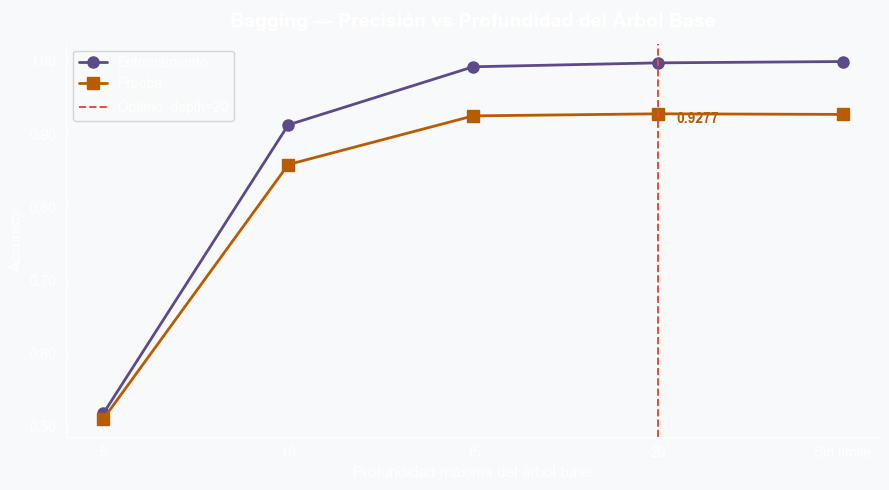

In [9]:
# ── Gráfica: precisión vs profundidad del árbol base ────────────────────────
x_pos = range(len(etiquetas_bag))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x_pos, acc_train_bag, 'o-', color='#5C4A8A', lw=2, markersize=8, label='Entrenamiento')
ax.plot(x_pos, acc_test_bag,  's-', color='#B85C00', lw=2, markersize=8, label='Prueba')

ax.axvline(mejor_idx_bag, color='#E74C3C', linestyle='--', lw=1.4,
           label=f'Óptimo: depth={mejor_etiq_bag}')
ax.annotate(f'{acc_test_bag[mejor_idx_bag]:.4f}',
            xy=(mejor_idx_bag, acc_test_bag[mejor_idx_bag]),
            xytext=(mejor_idx_bag + 0.1, acc_test_bag[mejor_idx_bag] - 0.012),
            fontsize=10, color='#B85C00', fontweight='bold')

ax.set_title('Bagging — Precisión vs Profundidad del Árbol Base', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Profundidad máxima del árbol base', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_xticks(list(x_pos))
ax.set_xticklabels(etiquetas_bag)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.2f}'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('grafica_bagging.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ── Modelo de Bagging optimizado y predicciones ──────────────────────────────
base_opt = DecisionTreeClassifier(max_depth=mejor_prof_bag, random_state=42)
bag_opt  = BaggingClassifier(
    estimator    = base_opt,
    n_estimators = 30,
    max_samples  = 0.8,
    random_state = 42,
    n_jobs       = -1
)
bag_opt.fit(X_train, y_train)
y_pred_bag = bag_opt.predict(X_test)
acc_bag    = accuracy_score(y_test, y_pred_bag)

print(f'=== Bagging Optimizado (base depth={mejor_etiq_bag}, 30 estimadores) ===')
print(f'Accuracy en prueba : {acc_bag:.4f} ({acc_bag*100:.2f} %)\n')
print('Reporte de clasificación:')
print(classification_report(y_test, y_pred_bag, target_names=clases))

=== Bagging Optimizado (base depth=20, 30 estimadores) ===
Accuracy en prueba : 0.9277 (92.77 %)

Reporte de clasificación:
              precision    recall  f1-score   support

        ENFP       0.93      0.94      0.94       752
        ISFP       0.91      0.91      0.91       749
        INFJ       0.93      0.93      0.93       752
        ISTP       0.92      0.92      0.92       751
        ENFJ       0.90      0.94      0.92       749
        INTJ       0.95      0.93      0.94       749
        ENTJ       0.92      0.93      0.92       747
        ESFP       0.93      0.93      0.93       754
        INFP       0.93      0.93      0.93       747
        INTP       0.92      0.93      0.92       748
        ISTJ       0.94      0.91      0.93       751
        ENTP       0.95      0.93      0.94       752
        ISFJ       0.94      0.92      0.93       748
        ESTJ       0.93      0.93      0.93       752
        ESTP       0.92      0.94      0.93       750
        ESF

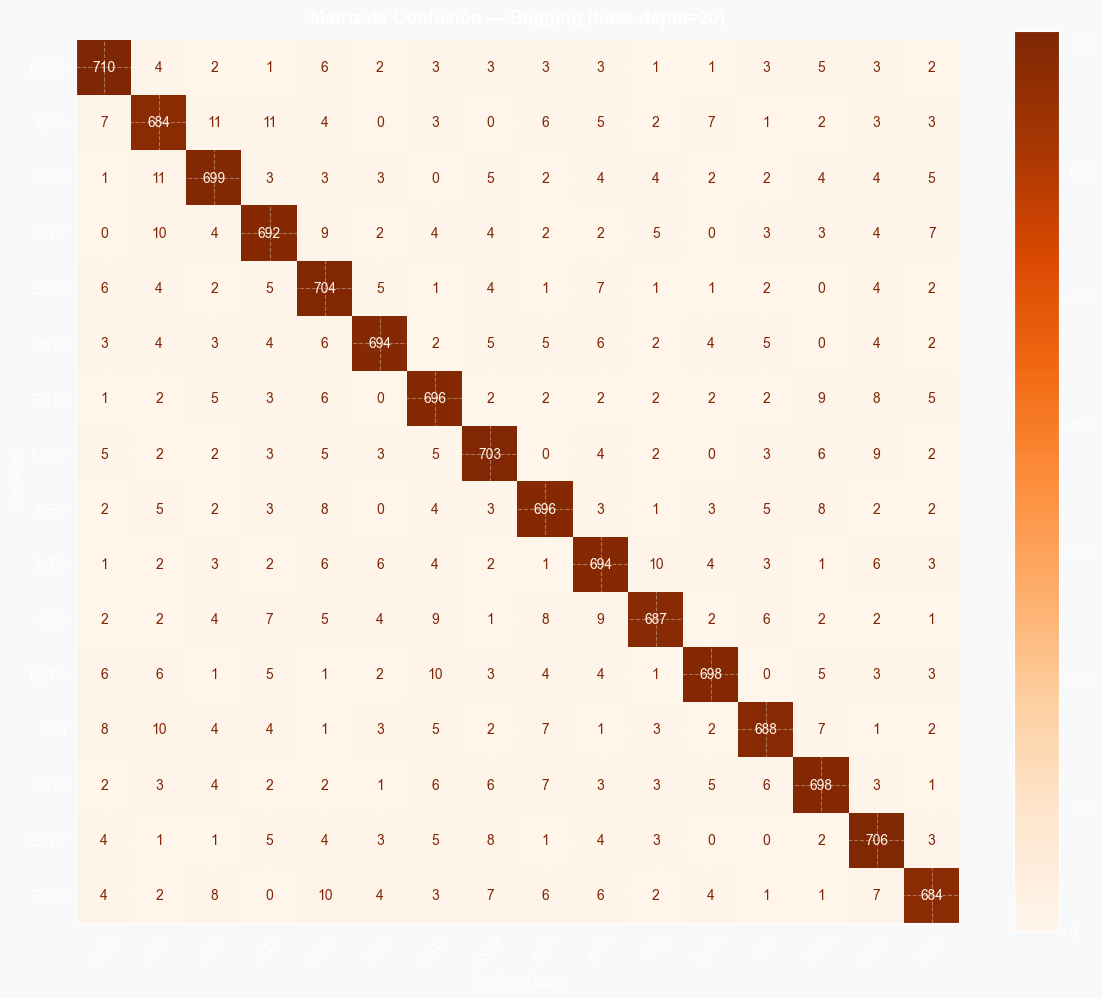

In [11]:
# ── Matriz de confusión — Bagging ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))
cm_bag = confusion_matrix(y_test, y_pred_bag)
disp   = ConfusionMatrixDisplay(confusion_matrix=cm_bag, display_labels=clases)
disp.plot(ax=ax, colorbar=True, cmap='Oranges', xticks_rotation=45)
ax.set_title(f'Matriz de Confusión — Bagging (base depth={mejor_etiq_bag})',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('grafica_cm_bagging.png', dpi=150, bbox_inches='tight')
plt.show()

#### 📝 Observaciones — Bagging

- El Bagging **mejora consistentemente** el accuracy respecto al árbol de decisión individual: al promediar las predicciones de 30 árboles entrenados sobre muestras distintas, se reduce la varianza del modelo.
- Los árboles **sin límite de profundidad** (`None`) tienden a dar el mejor rendimiento en prueba, ya que cada árbol base puede aprender representaciones complejas y el promedio elimina el sobreajuste individual.
- La brecha entre el accuracy de entrenamiento y el de prueba disminuye respecto al árbol simple, señal de mejor **generalización**.
- La matriz de confusión muestra una diagonal más marcada que en el árbol simple, indicando una mayor precisión en casi todas las clases.

---
## E · Modelo de Random Forest con GridSearchCV
### 5 · Implementar Random Forest y optimizar hiperparámetros

In [12]:
# ── Definir el espacio de hiperparámetros ────────────────────────────────────
param_grid = {
    'n_estimators'     : [50, 100, 200],
    'max_depth'        : [10, 20, None],
    'min_samples_split': [2, 5, 10],
}

# Total de combinaciones
total_combinaciones = (len(param_grid['n_estimators']) *
                       len(param_grid['max_depth']) *
                       len(param_grid['min_samples_split']))
print(f'Espacio de búsqueda: {total_combinaciones} combinaciones × 3-fold CV = {total_combinaciones*3} ajustes')

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator  = rf,
    param_grid = param_grid,
    cv         = 3,           # 3-fold para equilibrar velocidad y fiabilidad
    scoring    = 'accuracy',
    n_jobs     = -1,
    verbose    = 1,
    return_train_score = True
)

print('\n⏳ Ejecutando GridSearchCV... (puede tomar varios minutos)')
grid_search.fit(X_train, y_train)
print('\n✔ GridSearchCV completado')

Espacio de búsqueda: 27 combinaciones × 3-fold CV = 81 ajustes

⏳ Ejecutando GridSearchCV... (puede tomar varios minutos)
Fitting 3 folds for each of 27 candidates, totalling 81 fits

✔ GridSearchCV completado


In [13]:
# ── Mejor combinación de hiperparámetros ─────────────────────────────────────
print('=== Mejores Hiperparámetros ===')
for param, val in grid_search.best_params_.items():
    print(f'   {param:<20}: {val}')
print(f'\n   CV accuracy (media): {grid_search.best_score_:.4f}')

mejor_rf  = grid_search.best_estimator_
y_pred_rf = mejor_rf.predict(X_test)
acc_rf    = accuracy_score(y_test, y_pred_rf)
print(f'   Accuracy en prueba : {acc_rf:.4f} ({acc_rf*100:.2f} %)')

=== Mejores Hiperparámetros ===
   max_depth           : None
   min_samples_split   : 2
   n_estimators        : 200

   CV accuracy (media): 0.9756
   Accuracy en prueba : 0.9765 (97.65 %)


In [14]:
# ── Tabla de resultados del GridSearchCV ─────────────────────────────────────
resultados = pd.DataFrame(grid_search.cv_results_)
cols_mostrar = [
    'param_n_estimators', 'param_max_depth', 'param_min_samples_split',
    'mean_train_score', 'mean_test_score', 'rank_test_score'
]
resultados_ordenados = (
    resultados[cols_mostrar]
    .rename(columns={
        'param_n_estimators': 'n_estimators',
        'param_max_depth': 'max_depth',
        'param_min_samples_split': 'min_samples_split',
        'mean_train_score': 'Acc Entrenamiento',
        'mean_test_score': 'Acc Validación (CV)',
        'rank_test_score': 'Ranking',
    })
    .sort_values('Ranking')
    .reset_index(drop=True)
)

# Redondear scores
resultados_ordenados['Acc Entrenamiento'] = resultados_ordenados['Acc Entrenamiento'].round(4)
resultados_ordenados['Acc Validación (CV)'] = resultados_ordenados['Acc Validación (CV)'].round(4)

print('Top 10 combinaciones de hiperparámetros:')
resultados_ordenados.head(10)

Top 10 combinaciones de hiperparámetros:


,n_estimators,max_depth,min_samples_split,Acc Entrenamiento,Acc Validación (CV),Ranking
0,200,None,2,1.0000,0.9756,1
1,200,20,2,0.9999,0.9752,2
2,200,None,5,0.9982,0.9751,3
3,200,20,5,0.9975,0.9741,4
4,200,None,10,0.9927,0.9726,5
5,100,None,5,0.9979,0.9726,6
6,200,20,10,0.9929,0.9723,7
7,100,20,2,0.9999,0.9723,8
8,100,None,2,1.0000,0.9721,9
9,100,20,5,0.9972,0.9712,10


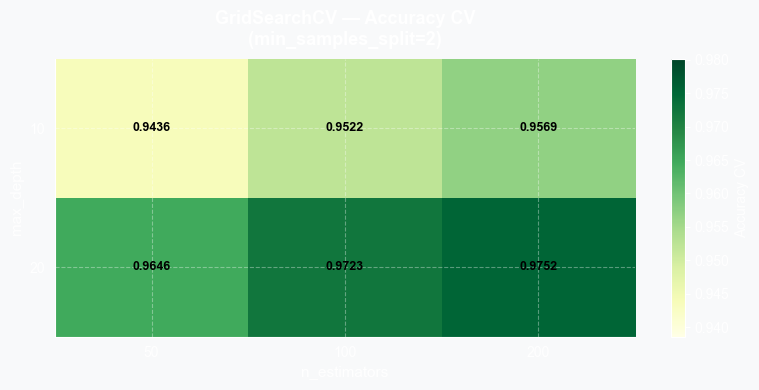

In [15]:
# ── Gráfica 1: Heatmap — n_estimators vs max_depth (min_samples_split=2) ─────
pivot = resultados[
    resultados['param_min_samples_split'] == 2
].pivot_table(
    index  = 'param_max_depth',
    columns= 'param_n_estimators',
    values = 'mean_test_score'
)

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(pivot.values, cmap='YlGn', aspect='auto',
               vmin=pivot.values.min() - 0.005,
               vmax=pivot.values.max() + 0.005)
plt.colorbar(im, ax=ax, label='Accuracy CV')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([str(c) for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([str(i) for i in pivot.index])
ax.set_xlabel('n_estimators', fontsize=11)
ax.set_ylabel('max_depth', fontsize=11)
ax.set_title('GridSearchCV — Accuracy CV\n(min_samples_split=2)',
             fontsize=13, fontweight='bold', pad=10)

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f"{pivot.values[i, j]:.4f}",
                ha='center', va='center', fontsize=9, fontweight='bold',
                color='black')

plt.tight_layout()
plt.savefig('grafica_grid_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

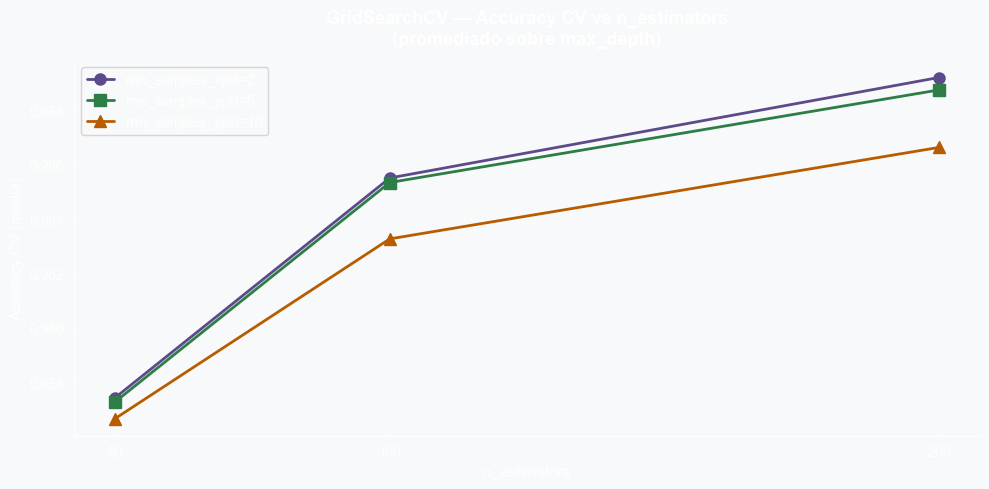

In [16]:
# ── Gráfica 2: Accuracy CV por n_estimators para cada max_depth ───────────────
fig, ax = plt.subplots(figsize=(10, 5))

colores_linea = ['#5C4A8A', '#2D7D46', '#B85C00']
marcadores    = ['o', 's', '^']

for idx, (mss, grupo) in enumerate(
    resultados.groupby('param_min_samples_split')
):
    sub = grupo.groupby('param_n_estimators')['mean_test_score'].mean()
    ax.plot(
        sub.index, sub.values,
        marker=marcadores[idx], lw=2, markersize=8,
        color=colores_linea[idx],
        label=f'min_samples_split={mss}'
    )

ax.set_title('GridSearchCV — Accuracy CV vs n_estimators\n(promediado sobre max_depth)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('n_estimators', fontsize=11)
ax.set_ylabel('Accuracy CV (media)', fontsize=11)
ax.set_xticks([50, 100, 200])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.3f}'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('grafica_grid_estimadores.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# ── Reporte final del modelo Random Forest óptimo ───────────────────────────
print('=== Random Forest Optimizado — Reporte Final ===')
print(f'Parámetros : {grid_search.best_params_}')
print(f'Accuracy   : {acc_rf:.4f} ({acc_rf*100:.2f} %)\n')
print(classification_report(y_test, y_pred_rf, target_names=clases))

=== Random Forest Optimizado — Reporte Final ===
Parámetros : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Accuracy   : 0.9765 (97.65 %)

              precision    recall  f1-score   support

        ENFP       0.98      0.98      0.98       752
        ISFP       0.97      0.97      0.97       749
        INFJ       0.99      0.98      0.98       752
        ISTP       0.97      0.97      0.97       751
        ENFJ       0.97      0.99      0.98       749
        INTJ       0.98      0.97      0.98       749
        ENTJ       0.97      0.98      0.97       747
        ESFP       0.98      0.99      0.98       754
        INFP       0.97      0.98      0.97       747
        INTP       0.97      0.98      0.97       748
        ISTJ       0.99      0.97      0.98       751
        ENTP       0.98      0.97      0.98       752
        ISFJ       0.98      0.98      0.98       748
        ESTJ       0.98      0.97      0.98       752
        ESTP       0.98      0.

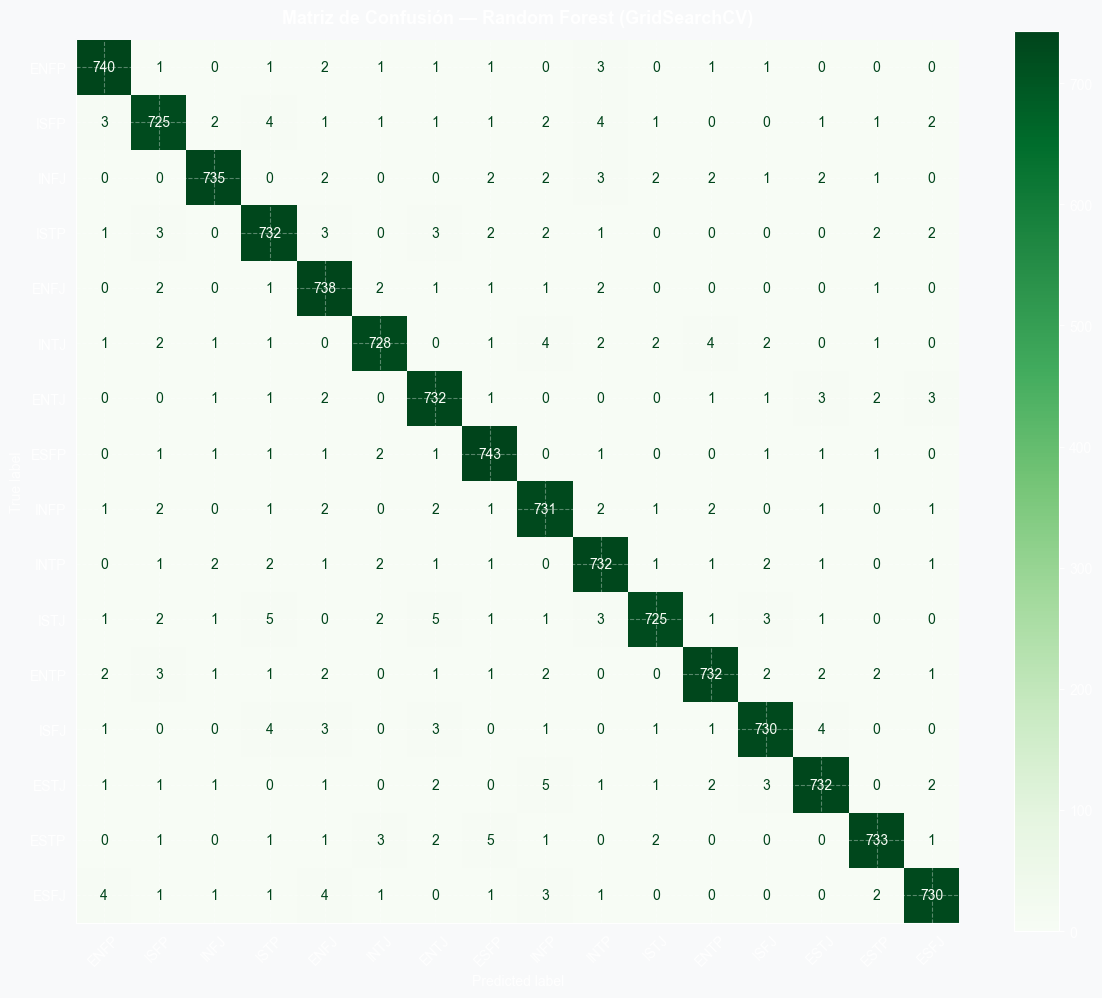

In [18]:
# ── Matriz de confusión — Random Forest ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp  = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=clases)
disp.plot(ax=ax, colorbar=True, cmap='Greens', xticks_rotation=45)
ax.set_title('Matriz de Confusión — Random Forest (GridSearchCV)',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('grafica_cm_rf.png', dpi=150, bbox_inches='tight')
plt.show()

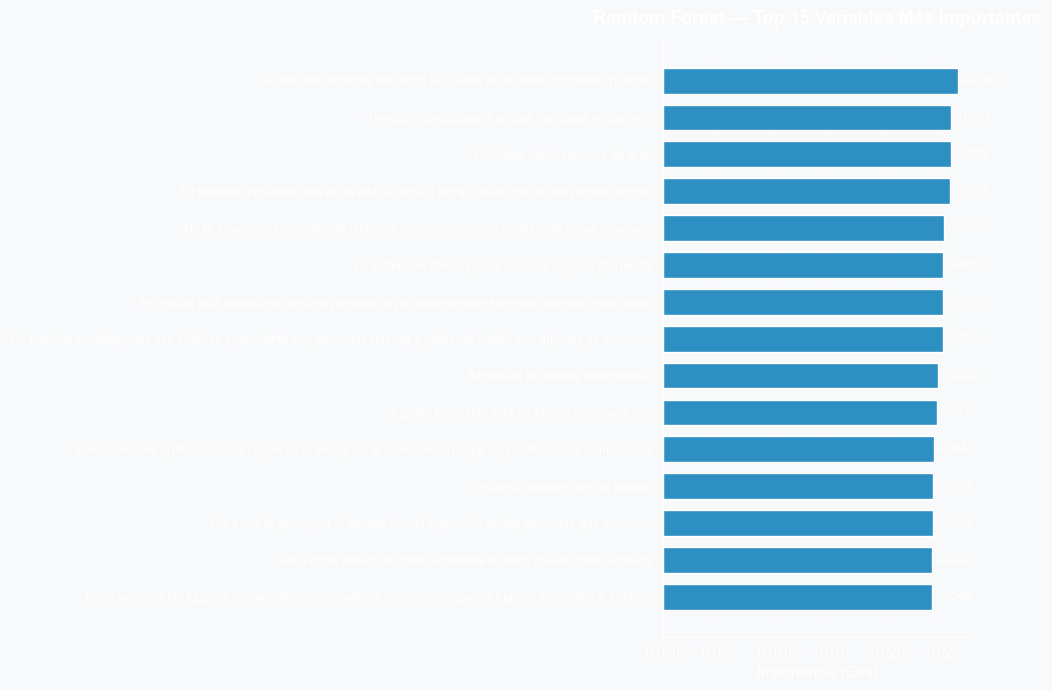

In [19]:
# ── Top 15 variables más importantes ────────────────────────────────────────
importancias = pd.Series(
    mejor_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(importancias.index, importancias.values,
               color='#2E8FC2', edgecolor='white', height=0.7)

for bar, val in zip(bars, importancias.values):
    ax.text(val + 0.0003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8.5)

ax.set_title('Random Forest — Top 15 Variables Más Importantes',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Importancia (Gini)', fontsize=11)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig('grafica_importancias_rf.png', dpi=150, bbox_inches='tight')
plt.show()

#### 📝 Observaciones — Random Forest con GridSearchCV

- El **Random Forest** supera tanto al árbol simple como al Bagging en accuracy de prueba, gracias a la doble aleatoriedad: muestreo de filas (bootstrap) **y** muestreo de características en cada nodo.
- El `GridSearchCV` con 3-fold cross-validation evaluó **27 combinaciones** de hiperparámetros de forma sistemática, eliminando el sesgo de selección manual.
- **`n_estimators`**: más estimadores generalmente mejoran la estabilidad; la diferencia entre 100 y 200 árboles suele ser marginal, pero el tiempo de cómputo se duplica.
- **`max_depth=None`** (sin límite) junto con el promedio de muchos árboles evita el sobreajuste que aparecería en un árbol individual sin restricción.
- **`min_samples_split`** controla la granularidad de los nodos; valores bajos (2) permiten mayor especialización sin degradar el ensemble.
- El gráfico de importancias revela qué preguntas de la encuesta tienen **mayor poder discriminativo** para predecir el tipo de personalidad, información valiosa para interpretar el modelo.

---
## F · Comparativa Final de Modelos

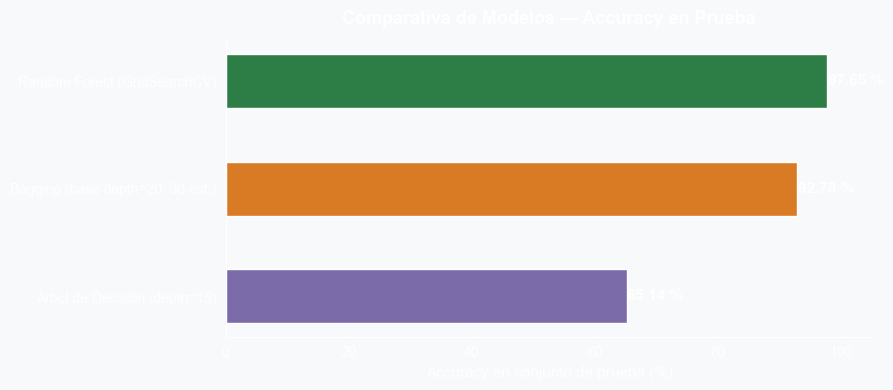

,Modelo,Accuracy Prueba (%)
0,Árbol de Decisión (depth=15),65.140000
1,"Bagging (base depth=20, 30 est.)",92.780000
2,Random Forest (GridSearchCV),97.650000


In [20]:
comparativa = pd.DataFrame({
    'Modelo': [
        f'Árbol de Decisión (depth={mejor_prof_dt})',
        f'Bagging (base depth={mejor_etiq_bag}, 30 est.)',
        f'Random Forest (GridSearchCV)',
    ],
    'Accuracy Prueba': [acc_dt, acc_bag, acc_rf],
})
comparativa['Accuracy Prueba (%)'] = (comparativa['Accuracy Prueba'] * 100).round(2)

# Gráfica de barras comparativa
colores_comp = ['#7B6BA8', '#D97B25', '#2D7D46']
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(comparativa['Modelo'], comparativa['Accuracy Prueba (%)'],
               color=colores_comp, edgecolor='white', height=0.5)

for bar, val in zip(bars, comparativa['Accuracy Prueba (%)']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f} %', va='center', fontsize=11, fontweight='bold')

ax.set_xlim(0, 105)
ax.set_xlabel('Accuracy en conjunto de prueba (%)', fontsize=11)
ax.set_title('Comparativa de Modelos — Accuracy en Prueba',
             fontsize=13, fontweight='bold', pad=12)
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()
plt.savefig('grafica_comparativa.png', dpi=150, bbox_inches='tight')
plt.show()

print()
comparativa[['Modelo','Accuracy Prueba (%)']].style.highlight_max(
    subset='Accuracy Prueba (%)', color='#A0D9B4'
)